<a href="https://colab.research.google.com/github/poojya100/6thSem-ML-Lab/blob/main/%E2%80%9C1BM23CS303_Lab-6_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree

1. With library

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("iris (1) (1).csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Encode target if categorical
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Without library

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Entropy function
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

# Information Gain
def information_gain(X_column, y, threshold):
    parent_entropy = entropy(y)

    left_mask = X_column <= threshold
    right_mask = X_column > threshold

    if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
        return 0

    n = len(y)
    n_left = len(y[left_mask])
    n_right = len(y[right_mask])

    child_entropy = (n_left/n)*entropy(y[left_mask]) + (n_right/n)*entropy(y[right_mask])

    return parent_entropy - child_entropy

# Find best split
def best_split(X, y):
    best_gain = -1
    split_idx, split_thresh = None, None

    for col in range(X.shape[1]):
        thresholds = np.unique(X[:, col])
        for thresh in thresholds:
            gain = information_gain(X[:, col], y, thresh)
            if gain > best_gain:
                best_gain = gain
                split_idx = col
                split_thresh = thresh

    return split_idx, split_thresh

# Simple tree node
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# Build tree
def build_tree(X, y, depth=0, max_depth=3):

    if len(set(y)) == 1 or depth >= max_depth:
        return Node(value=np.bincount(y).argmax())

    feat, thresh = best_split(X, y)

    left_idx = X[:, feat] <= thresh
    right_idx = X[:, feat] > thresh

    left = build_tree(X[left_idx], y[left_idx], depth+1, max_depth)
    right = build_tree(X[right_idx], y[right_idx], depth+1, max_depth)

    return Node(feat, thresh, left, right)

# Prediction
def predict_sample(node, x):
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

def predict(tree, X):
    return np.array([predict_sample(tree, x) for x in X])

# Load dataset (works for iris or drug)
data = pd.read_csv("iris (1) (1).csv")

# Encode categorical if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train tree
tree = build_tree(X_train, y_train)

# Predict
y_pred = predict(tree, X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9333333333333333
Confusion Matrix:
 [[ 5  0  0]
 [ 0  8  2]
 [ 0  0 15]]


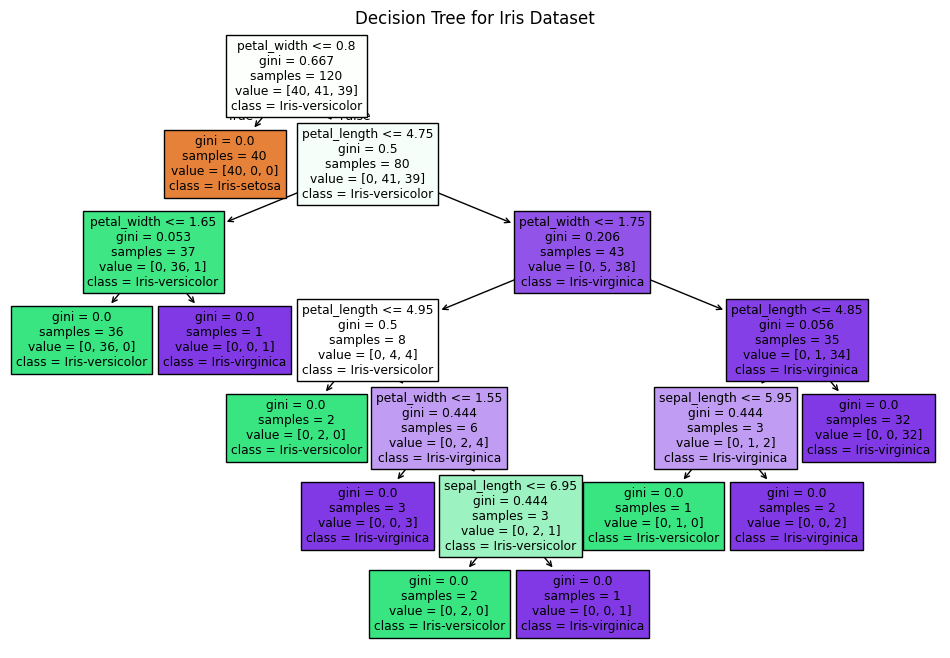

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load dataset
data = pd.read_csv("iris (1) (1).csv")

# Features and target
X = data.drop("species", axis=1)
y = data["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Plot tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True)

plt.title("Decision Tree for Iris Dataset")
plt.show()


2.With library

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("drug.csv")

# Convert categorical columns to numeric
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


Without Library

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Entropy function
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

# Information Gain
def information_gain(X_column, y, threshold):
    parent_entropy = entropy(y)

    left_mask = X_column <= threshold
    right_mask = X_column > threshold

    if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
        return 0

    n = len(y)
    n_left = len(y[left_mask])
    n_right = len(y[right_mask])

    child_entropy = (n_left/n)*entropy(y[left_mask]) + (n_right/n)*entropy(y[right_mask])

    return parent_entropy - child_entropy

# Find best split
def best_split(X, y):
    best_gain = -1
    split_idx, split_thresh = None, None

    for col in range(X.shape[1]):
        thresholds = np.unique(X[:, col])
        for thresh in thresholds:
            gain = information_gain(X[:, col], y, thresh)
            if gain > best_gain:
                best_gain = gain
                split_idx = col
                split_thresh = thresh

    return split_idx, split_thresh

# Simple tree node
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# Build tree
def build_tree(X, y, depth=0, max_depth=3):

    if len(set(y)) == 1 or depth >= max_depth:
        return Node(value=np.bincount(y).argmax())

    feat, thresh = best_split(X, y)

    left_idx = X[:, feat] <= thresh
    right_idx = X[:, feat] > thresh

    left = build_tree(X[left_idx], y[left_idx], depth+1, max_depth)
    right = build_tree(X[right_idx], y[right_idx], depth+1, max_depth)

    return Node(feat, thresh, left, right)

# Prediction
def predict_sample(node, x):
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

def predict(tree, X):
    return np.array([predict_sample(tree, x) for x in X])

# Load dataset (works for iris or drug)
data = pd.read_csv("drug.csv")

# Encode categorical if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train tree
tree = build_tree(X_train, y_train)

# Predict
y_pred = predict(tree, X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9
Confusion Matrix:
 [[ 6  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  0  4  0]
 [ 0  0  0 10  0]
 [ 0  0  0  0 15]]


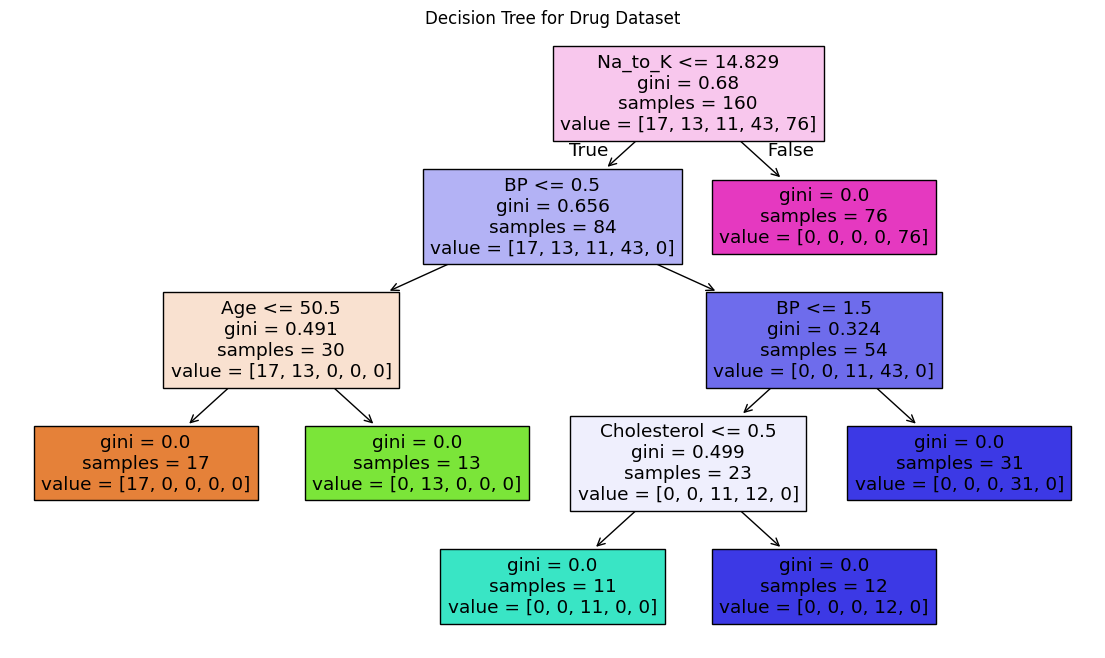

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("drug.csv")

# Encode categorical columns
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop("Drug", axis=1)
y = data["Drug"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Plot tree
plt.figure(figsize=(14,8))
plot_tree(model,
          feature_names=X.columns,
          filled=True)

plt.title("Decision Tree for Drug Dataset")
plt.show()


3. Petrol Dataset

With Library

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
data = pd.read_csv("petrol_consumption.csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Regression Tree
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 91.4
Mean Squared Error: 17320.2
Root Mean Squared Error: 131.6062308555336


Without Library

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
data = pd.read_csv("petrol_consumption.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


# Mean Squared Error
def mse(y):
    return np.mean((y - np.mean(y))**2)


# Find best split
def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_error = float("inf")

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])

        for t in thresholds:
            left = y[X[:, feature] <= t]
            right = y[X[:, feature] > t]

            if len(left) == 0 or len(right) == 0:
                continue

            error = (len(left)/len(y))*mse(left) + (len(right)/len(y))*mse(right)

            if error < best_error:
                best_error = error
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold


# Tree node
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


# Build tree
def build_tree(X, y, depth=0, max_depth=3):

    if len(y) == 0 or depth >= max_depth:
        return Node(value=np.mean(y))

    feature, threshold = best_split(X, y)

    if feature is None:
        return Node(value=np.mean(y))

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left = build_tree(X[left_mask], y[left_mask], depth+1, max_depth)
    right = build_tree(X[right_mask], y[right_mask], depth+1, max_depth)

    return Node(feature, threshold, left, right)


# Prediction for one sample
def predict_sample(node, x):

    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)


# Predict for dataset
def predict(tree, X):
    return np.array([predict_sample(tree, x) for x in X])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
tree = build_tree(X_train, y_train)

# Predictions
y_pred = predict(tree, X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 80.62857142857142
Mean Squared Error: 14718.398909297053
Root Mean Squared Error: 121.31940862573083


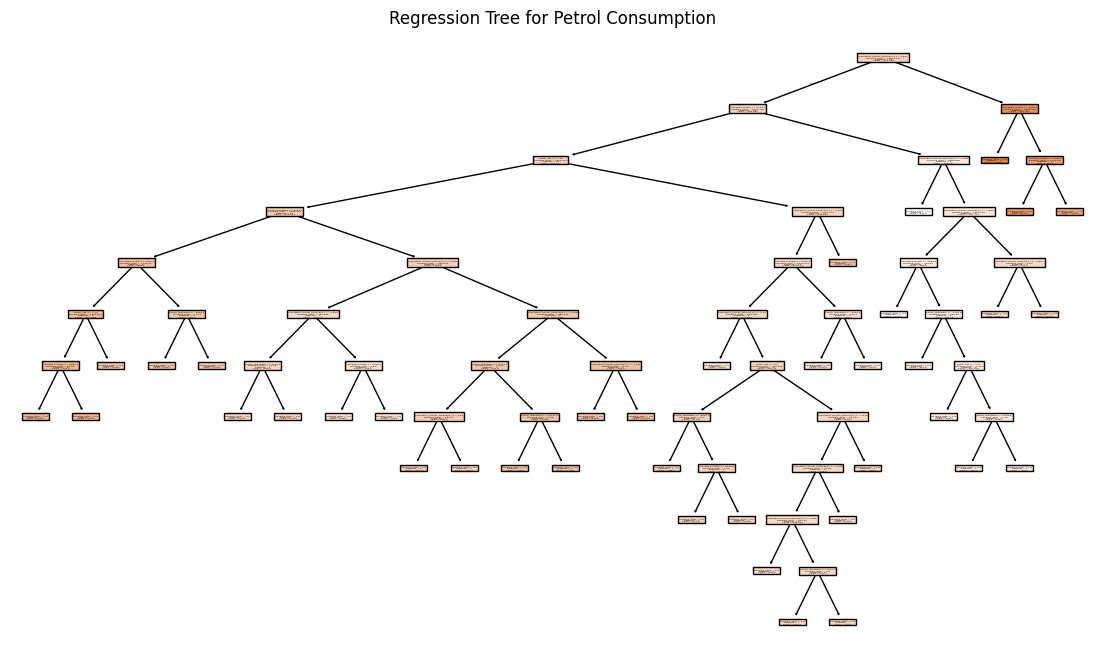

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Load dataset
data = pd.read_csv("petrol_consumption.csv")

# Features and target
X = data.drop("Petrol_Consumption", axis=1)
y = data["Petrol_Consumption"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train regression tree
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Plot tree
plt.figure(figsize=(14,8))
plot_tree(model,
          feature_names=X.columns,
          filled=True)

plt.title("Regression Tree for Petrol Consumption")
plt.show()